# Custom Keyword basics

Steps:
* Create a Python class with `@library` annotation from the `robot.api.deco` package
* Create a method with `@keyword` annotation from the `robot.api.deco` package

> Note that:
> * **keywords** are nothing but python methods with `@keyword` annotation.
> * The method name becomes the keyword name.
> * Robot framework keywords are case insensitive.

## `shop.py`

```python
from robot.api.deco import library, keyword


@library
class Shop:

    def __init__(self):
        pass

    # method name will be converter to keyword
    @keyword
    def hello_world(self):
        print("Hello World!!")
```

## `custom_keyword_demo.robot`

```
*** Settings ***
Documentation    To validate custom keyword
Library    ../custom_library/shop.py

*** Test Cases ***

Validate hello world custom keyword
    Execute Hello World custom keyword

*** Keywords ***
Execute Hello World custom keyword
    Hello World
```

# Custom Selenium Keyword

## Existing complex robot logic

**Test Case**:
```
Select the Card    Blackberry
```

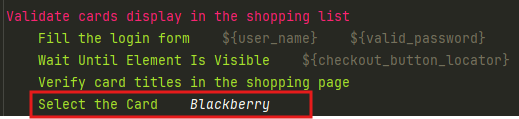

**Keyword implementation**

```
Select the Card
    [arguments]    ${card_name}

    # Retrieve list of web elements
    @{elements}=    Get Webelements       css:.card-title

    # Variable assignment
    ${index}=    Set Variable    1

    # Find the index of card_name
    FOR    ${element}  IN    @{elements}
        Exit For Loop If    '${card_name}'=='${element.text}'
        ${index}=     Evaluate    ${index} + 1
    END

    Click Button    xpath:(//*[@class='card-footer'])[${index}]/button
```

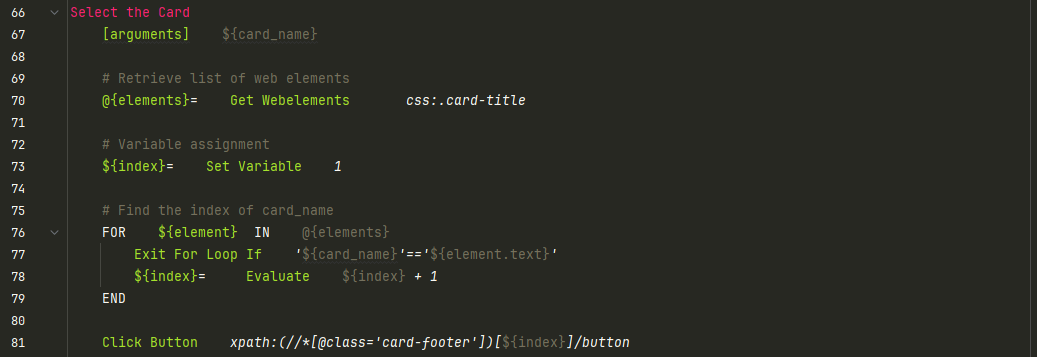

## Simplified logic with custom keyword

**Custom Keyword Implementation**

```python
    @keyword
    def add_items_to_cart_and_checkout(self, product_list):

        # Get WebElements   css:.card-title
        product_titles = self.selenium_lib.get_webelements("css:.card-title")

        i = 1
        for product in product_titles:
            if product.text in product_list:
                self.selenium_lib.click_button(f"xpath:(//*[@class='card-footer'])[{i}]/button")
            i = i + 1
```

**Usage**


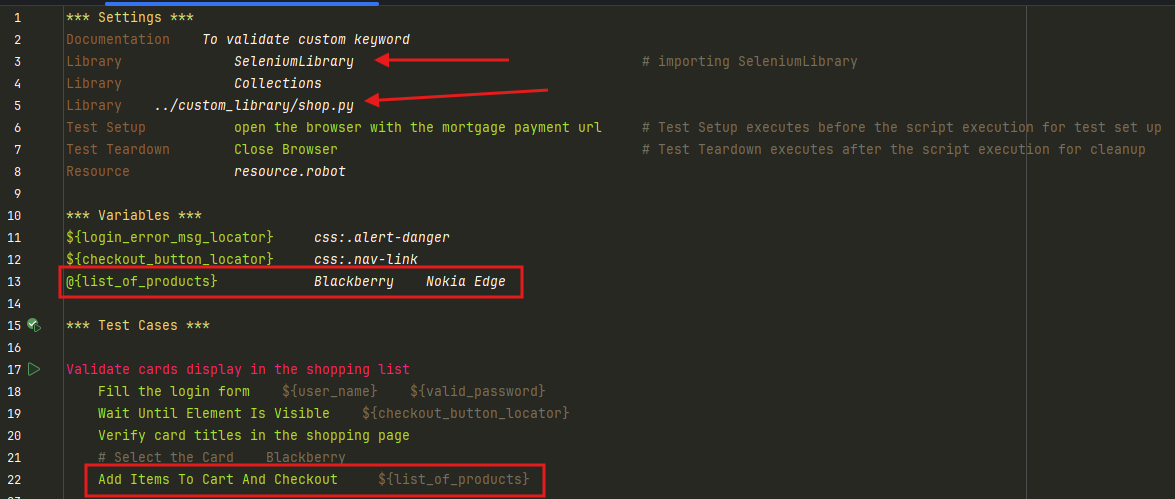

> **Note that**:
> * We need to import SeleniumLibrary first, then our custom library.
> * Otherwise, our custom library won't be able to find the SeleniumLibrary instance.